In [53]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [54]:
df = pd.read_excel('dados_aula12_vendas.xlsx')

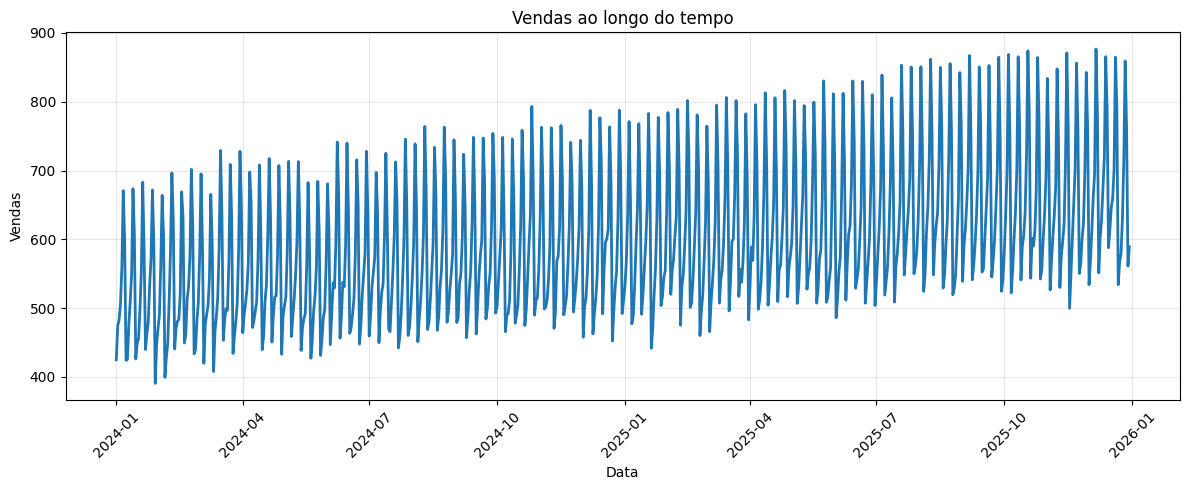

In [55]:
import matplotlib.pyplot as plt

df['data'] = pd.to_datetime(df['data'])

plt.figure(figsize=(12, 5))
plt.plot(df['data'], df['vendas'], linewidth=2)
plt.title('Vendas ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [56]:
df['data'] = pd.to_datetime(df['data'])
df.set_index('data', inplace=True)
feat = pd.DataFrame(index=df.index)
feat['y'] = df['vendas']

for lag in [7, 12, 14, 21, 28]:
    feat[f'lag_{lag}'] = df['vendas'].shift(lag)

feat[['y', 'lag_7', 'lag_12', 'lag_14', 'lag_21', 'lag_28']].tail(10)

,y,lag_7,lag_12,lag_14,lag_21,lag_28
data,,,,,,
2025-12-21,792.850582,788.830754,602.338450,785.561982,762.063070,758.214338
2025-12-22,534.098081,587.845175,628.968042,551.271173,534.157213,550.344694
2025-12-23,566.567477,614.061580,673.425154,602.338450,568.715816,564.557060
2025-12-24,579.241861,646.427938,719.027643,628.968042,612.923382,600.896758
2025-12-25,628.235783,659.777742,865.504731,673.425154,661.084290,624.275162
2025-12-26,713.892827,701.306068,788.830754,719.027643,695.444197,700.156052
2025-12-27,859.147324,864.836124,587.845175,865.504731,876.544684,842.562613
2025-12-28,763.263084,792.850582,614.061580,788.830754,785.561982,762.063070
2025-12-29,561.139707,534.098081,646.427938,587.845175,551.271173,534.157213


In [57]:
h=7

feat['roll_mean_7'] = df['vendas'].shift(h).rolling(window=7).mean()
feat['roll_mean_12'] = df['vendas'].shift(h).rolling(window=12).mean()
feat['roll_mean_14'] = df['vendas'].shift(h).rolling(window=14).mean()
feat['roll_mean_21'] = df['vendas'].shift(h).rolling(window=21).mean()
feat['roll_mean_28'] = df['vendas'].shift(h).rolling(window=28).mean()

In [58]:
feat['dow'] = feat.index.dayofweek
feat['month'] = feat.index.month
feat['is_weekend'] = (feat.dow >= 5).astype(int)


feat[['dow', 'month', 'is_weekend']].tail(10)


,dow,month,is_weekend
data,,,
2025-12-21,6,12,1
2025-12-22,0,12,0
2025-12-23,1,12,0
2025-12-24,2,12,0
2025-12-25,3,12,0
2025-12-26,4,12,0
2025-12-27,5,12,1
2025-12-28,6,12,1
2025-12-29,0,12,0


In [59]:
#reduzindo distancia dos dow
#enconding ciclico

feat['dow_sin'] = np.sin(2 * np.pi * feat['dow']/7)
feat['dow_cos'] = np.cos(2 * np.pi * feat['dow']/7)

feat['month_sin'] = np.sin(2 * np.pi * feat['month']/12)
feat['month_cos'] = np.cos(2 * np.pi * feat['month']/12)

feat[['dow', 'dow_sin', 'dow_cos', 'month', 'month_sin', 'month_cos']].tail(10)

,dow,dow_sin,dow_cos,month,month_sin,month_cos
data,,,,,,
2025-12-21,6,-0.781831,0.623490,12,-2.449294e-16,1.0
2025-12-22,0,0.000000,1.000000,12,-2.449294e-16,1.0
2025-12-23,1,0.781831,0.623490,12,-2.449294e-16,1.0
2025-12-24,2,0.974928,-0.222521,12,-2.449294e-16,1.0
2025-12-25,3,0.433884,-0.900969,12,-2.449294e-16,1.0
2025-12-26,4,-0.433884,-0.900969,12,-2.449294e-16,1.0
2025-12-27,5,-0.974928,-0.222521,12,-2.449294e-16,1.0
2025-12-28,6,-0.781831,0.623490,12,-2.449294e-16,1.0
2025-12-29,0,0.000000,1.000000,12,-2.449294e-16,1.0


In [60]:
# Remove as linhas iniciais sem histórico suficiente para calcular os lags e médias móveis
feat = feat.dropna().copy()

# Separação temporal 80/20 (sem embaralhar a série)
teste_size = 0.2

train_size = int(len(feat) * (1 - teste_size))
test_size = len(feat) - train_size

train = feat.iloc[:train_size]
test = feat.iloc[train_size:]


Mean Absolute Error (MAE): 16.30


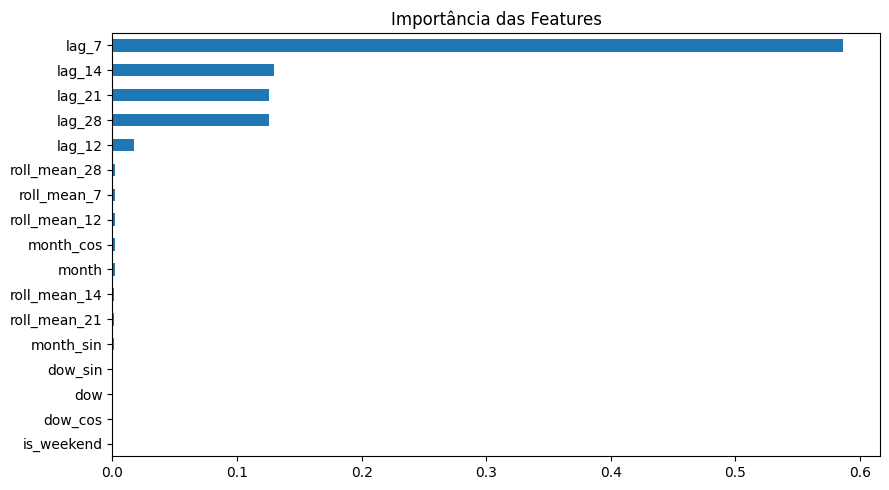

lag_7           0.5868
lag_14          0.1300
lag_21          0.1259
lag_28          0.1255
lag_12          0.0176
roll_mean_28    0.0020
roll_mean_7     0.0018
roll_mean_12    0.0017
month_cos       0.0017
month           0.0017
roll_mean_14    0.0016
roll_mean_21    0.0015
month_sin       0.0015
dow_sin         0.0003
dow             0.0002
dow_cos         0.0002
is_weekend      0.0000
dtype: float64


In [61]:
feature_cols = [col for col in feat.columns if col != 'y']

modelo = RandomForestRegressor(n_estimators=200, random_state=42)
modelo.fit(train[feature_cols], train['y'])
previsoes = modelo.predict(test[feature_cols])

mae = mean_absolute_error(test['y'], previsoes)
print(f'Mean Absolute Error (MAE): {mae:.2f}')

importancias = pd.Series(modelo.feature_importances_, index=feature_cols).sort_values()
fig,ax = plt.subplots(figsize=(9,5))
importancias.plot(kind='barh', ax=ax)
ax.set_title('Importância das Features')
plt.tight_layout()
plt.show()

print(importancias.sort_values(ascending=False).round(4))